## Import Library

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    cross_validate
)

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## Load Dataset

In [39]:
df = pd.read_csv('../Data/raw/PhiUSIIL_Phishing_URL_Dataset.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


## Preprocessing

### 1. Drop kolom 

In [40]:
# Metadata
metadata_cols = [
    "FILENAME",
    "URL",
    "Domain",
    "Title"
]

# Fitur yang berpotensi leakage
dominans_cols = [
    "URLSimilarityIndex",
    "URLTitleMatchScore",
    "DomainTitleMatchScore",
    "TLDLegitimateProb",
    "URLCharProb"
]

drop_cols = metadata_cols + dominans_cols

existing_cols = [
    col for col in drop_cols
    if col in df.columns
]

df_model = df.drop(columns=existing_cols)

print(f"Kolom dihapus: {len(existing_cols)}")
print(f"Shape setelah drop: {df_model.shape}")

Kolom dihapus: 9
Shape setelah drop: (235795, 47)


### 2. Features dan Target

In [41]:
X = df_model.drop(columns=['label'])
y = df_model['label']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nTarget distribution:\n{y.value_counts(normalize=True)}')


Features shape: (235795, 46)
Target shape: (235795,)

Target distribution:
label
1    0.571895
0    0.428105
Name: proportion, dtype: float64


### 3. Training Test Split

In [42]:
from sklearn.pipeline import Pipeline

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    pipeline = Pipeline([
        ('feature_selection', SelectKBest(score_func=f_classif, k=21)),
        ('classifier', model)
    ])
    cv_scores = cross_val_score(
        pipeline,
        X_train, # Pastikan ini X_train_corr (data sebelum di-SelectKBest)
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    pipeline.fit(X_train, y_train)
    y_pred_test = pipeline.predict(X_test)

### 4. Frequency Encoding TLD

In [43]:
if "TLD" in X_train.columns:
    freq_map = X_train["TLD"].value_counts(normalize=True)
    X_train["TLD"] = X_train["TLD"].map(freq_map)
    X_test["TLD"] = X_test["TLD"].map(freq_map)
    X_test["TLD"] = X_test["TLD"].fillna(0)

### 5. Correlation Analysis

In [44]:
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_features = [
    col
    for col in upper.columns
    if any(upper[col] > 0.90)
]

print("Jumlah fitur berkorelasi tinggi:")
print(len(high_corr_features))

high_corr_features

Jumlah fitur berkorelasi tinggi:
1


['NoOfLettersInURL']

### 6. Hapus fitur dengan korelasi tinggi

In [45]:
X_train_corr = X_train.drop(
    columns=high_corr_features,
    errors="ignore"
)

X_test_corr = X_test.drop(
    columns=high_corr_features,
    errors="ignore"
)

print(X_train_corr.shape)
print(X_test_corr.shape)

(188636, 45)
(47159, 45)


### 7. ANOVA Feature Selection

In [46]:
k_best = 21

selector = SelectKBest(
    score_func=f_classif,
    k=k_best
)

selector.fit(
    X_train_corr,
    y_train
)

selected_features = (
    X_train_corr.columns[
        selector.get_support()
    ]
)

print("Selected Features:")
print(selected_features.tolist())

Selected Features:
['DomainLength', 'CharContinuationRate', 'LetterRatioInURL', 'DegitRatioInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'HasTitle', 'HasFavicon', 'Robots', 'IsResponsive', 'HasDescription', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'Pay', 'HasCopyrightInfo', 'NoOfImage', 'NoOfJS', 'NoOfSelfRef', 'NoOfExternalRef']


### 8. Dataset Setelah Seleksi Fitur

In [47]:
X_train_selected = pd.DataFrame(
    selector.transform(X_train_corr),
    columns=selected_features,
    index=X_train_corr.index
)

X_test_selected = pd.DataFrame(
    selector.transform(X_test_corr),
    columns=selected_features,
    index=X_test_corr.index
)

print(X_train_selected.shape)
print(X_test_selected.shape)

(188636, 21)
(47159, 21)


### 9. Cross Validation Setup

In [48]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Modeling

### 1. Definisi Model & Fungsi Evaluasi

In [49]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba_test = model.predict_proba(X_test)[:, 1]
    else:
        y_proba_test = model.decision_function(X_test)

    metrics = {
        "Model": model_name,
        "CV F1": cv_scores.mean(),
        "Train Accuracy":accuracy_score(y_train, y_pred_train),
        "Test Accuracy":accuracy_score(y_test, y_pred_test),
        "Precision":precision_score(y_test, y_pred_test),
        "Recall":recall_score(y_test, y_pred_test),
        "F1-Score":f1_score(y_test, y_pred_test),
        "ROC AUC":roc_auc_score(y_test, y_proba_test),
        "PR AUC":
            average_precision_score(
                y_test,
                y_proba_test
            )
    }

    return metrics, y_pred_test, y_proba_test

#### 2. Definisi Kandidat Model

In [50]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
}


### 3. Training & Evaluasi Semua Model

In [51]:
results = []
predictions = {}

for name, model in models.items():
    print(f'Training {name}...')
    metrics, y_pred, y_proba = evaluate_model(
        model, X_train_selected, X_test_selected, y_train, y_test, name
    )
    results.append(metrics)
    predictions[name] = {'y_pred': y_pred, 'y_proba': y_proba}

# Summary table
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
results_df = results_df.sort_values('ROC AUC', ascending=False)
print('\n=== Model Comparison ===')
results_df

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

=== Model Comparison ===


,CV F1,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC AUC,PR AUC
Model,,,,,,,,
XGBoost,0.999805,0.999995,0.999682,0.999629,0.999815,0.999722,1.000000,1.000000
Random Forest,0.999629,1.000000,0.999449,0.999259,0.999778,0.999518,0.999998,0.999999
Logistic Regression,0.998712,0.998606,0.998558,0.998518,0.998962,0.998740,0.999942,0.999938
Decision Tree,0.998725,1.000000,0.998749,0.998888,0.998925,0.998906,0.998719,0.998429


### 4. Visualisasi Perbandingan Model

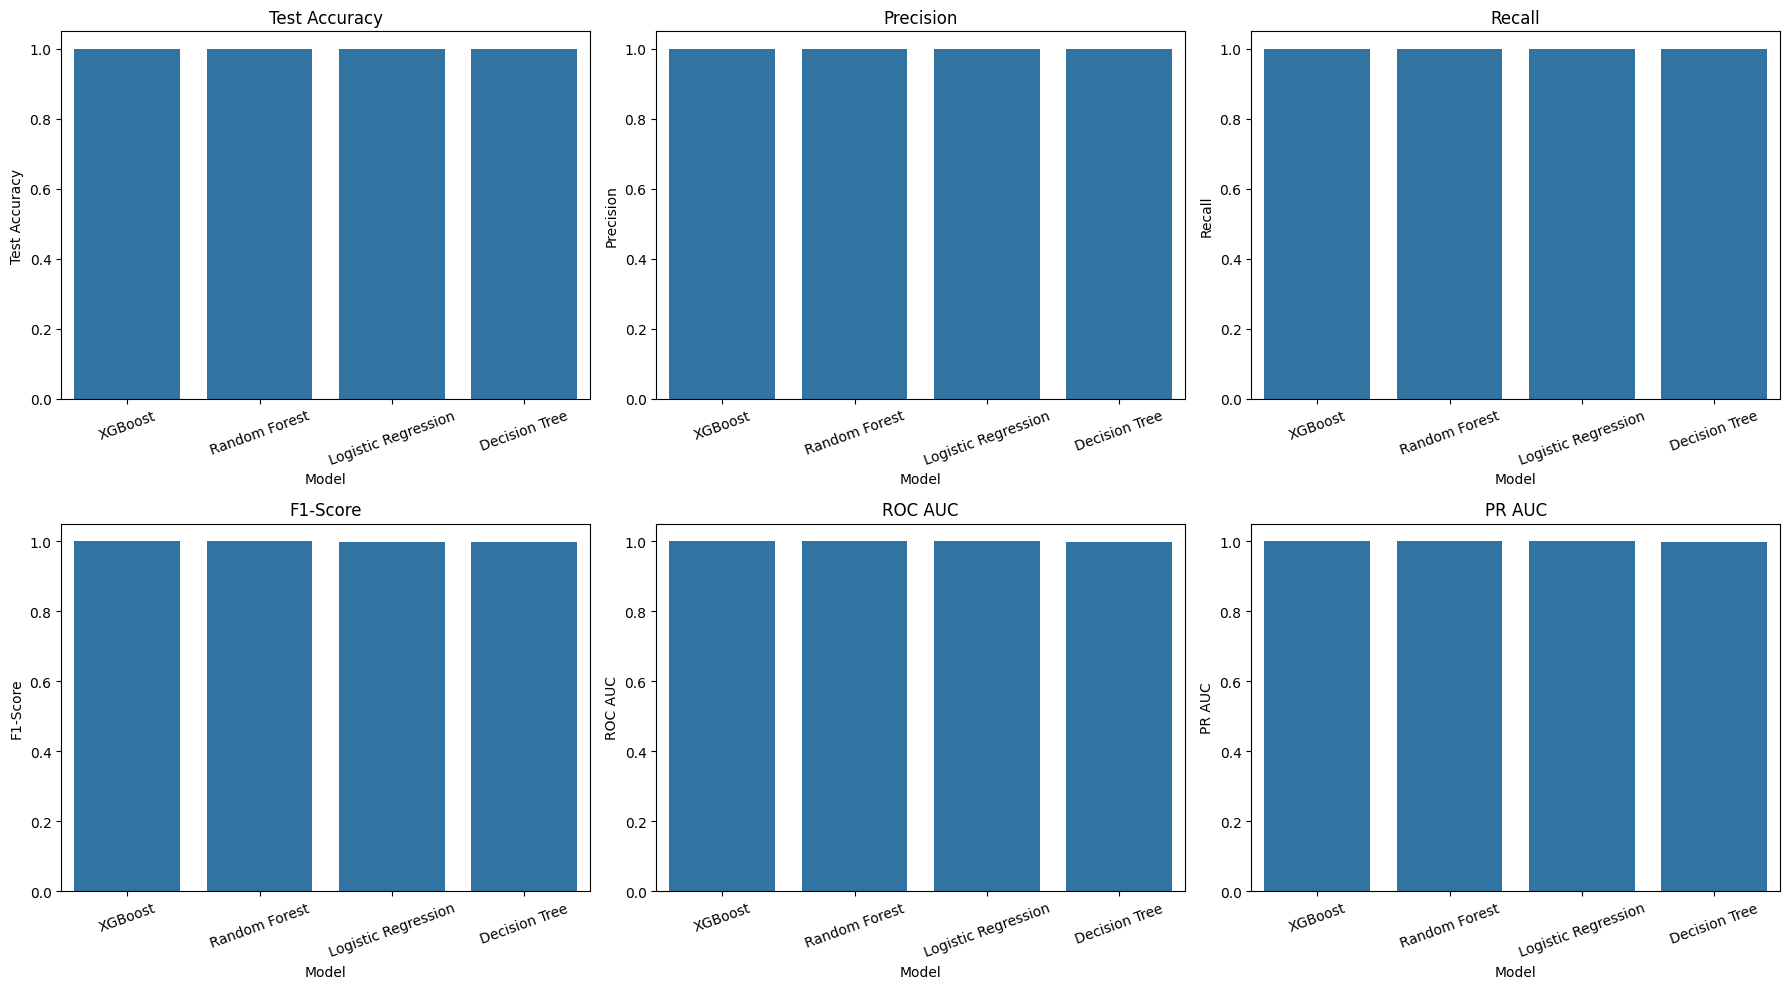

In [52]:
metrics_to_plot = [
    "Test Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC AUC",
    "PR AUC"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, metric in enumerate(metrics_to_plot):

    sns.barplot(
        data=results_df.reset_index(),
        x="Model",
        y=metric,
        ax=axes[i]
    )

    axes[i].set_title(metric)
    axes[i].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### 5. ROC Curve

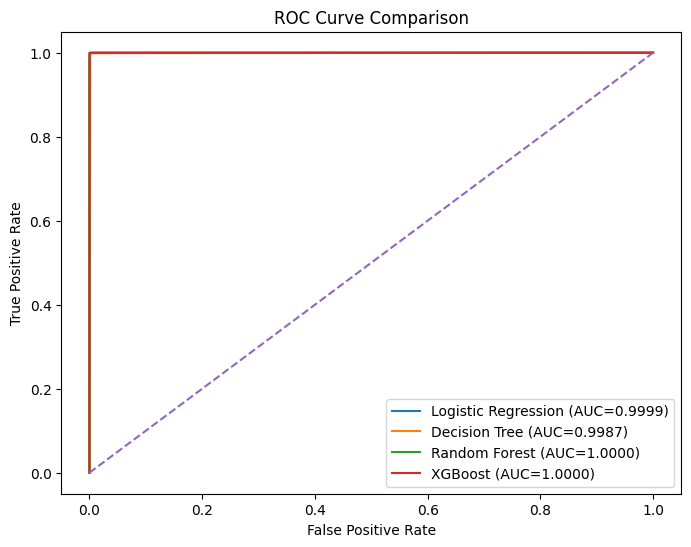

In [53]:
plt.figure(figsize=(8,6))

for model_name, pred in predictions.items():
    fpr, tpr, _ = roc_curve(
        y_test,
        pred["y_proba"]
    )
    auc_score = roc_auc_score(
        y_test,
        pred["y_proba"]
    )
    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc_score:.4f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

#### 6. Confusion Matrix untuk Model Terbaik

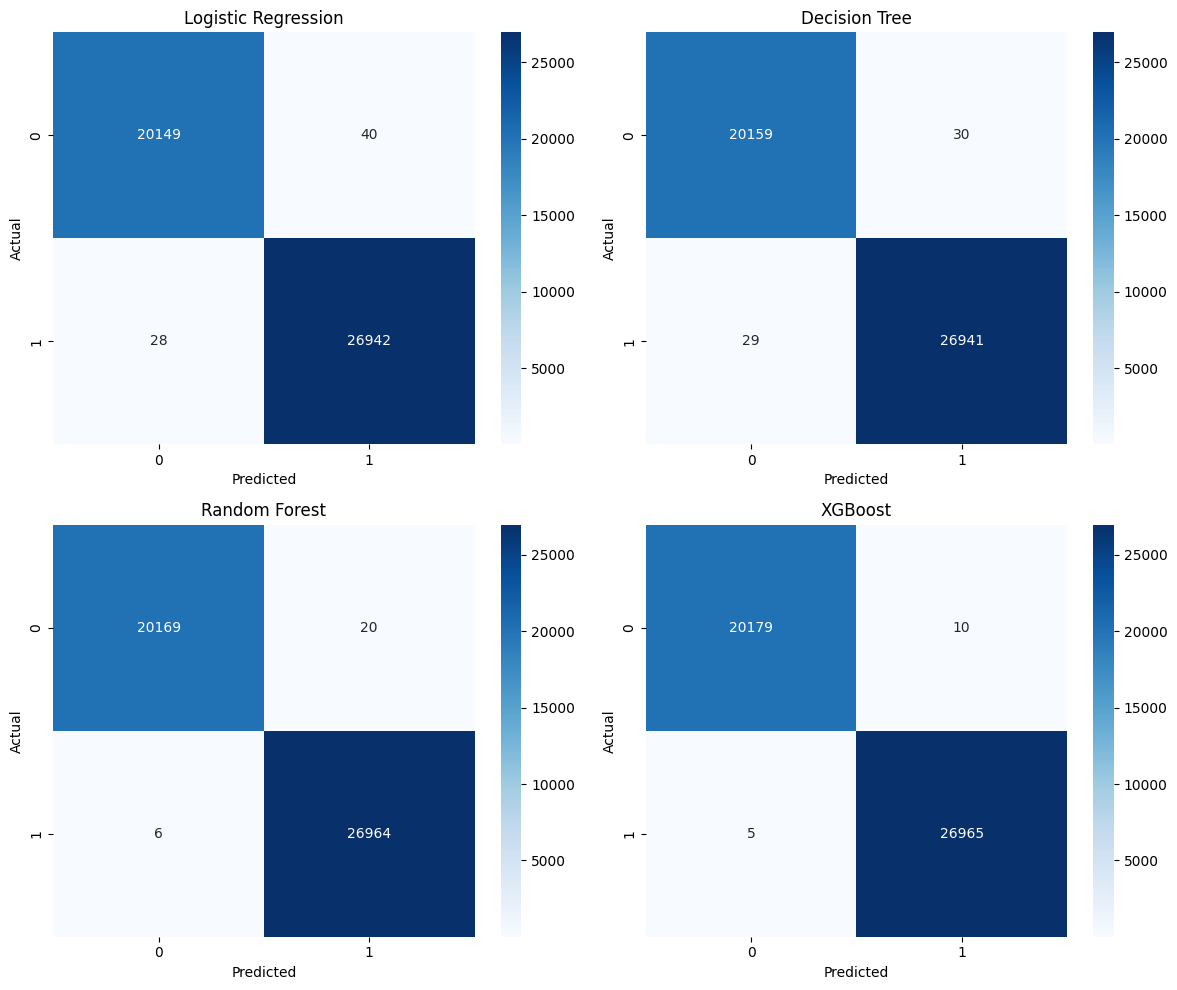

In [54]:
fig, axes = plt.subplots(2,2,figsize=(12,10))
axes = axes.flatten()
for idx, (model_name, pred) in enumerate(predictions.items()):

    cm = confusion_matrix(
        y_test,
        pred["y_pred"]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[idx]
    )

    axes[idx].set_title(model_name)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.show()

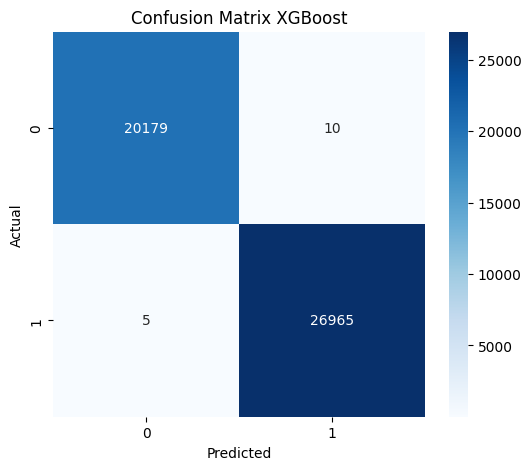

In [55]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Feature Importance

Best Model: XGBoost


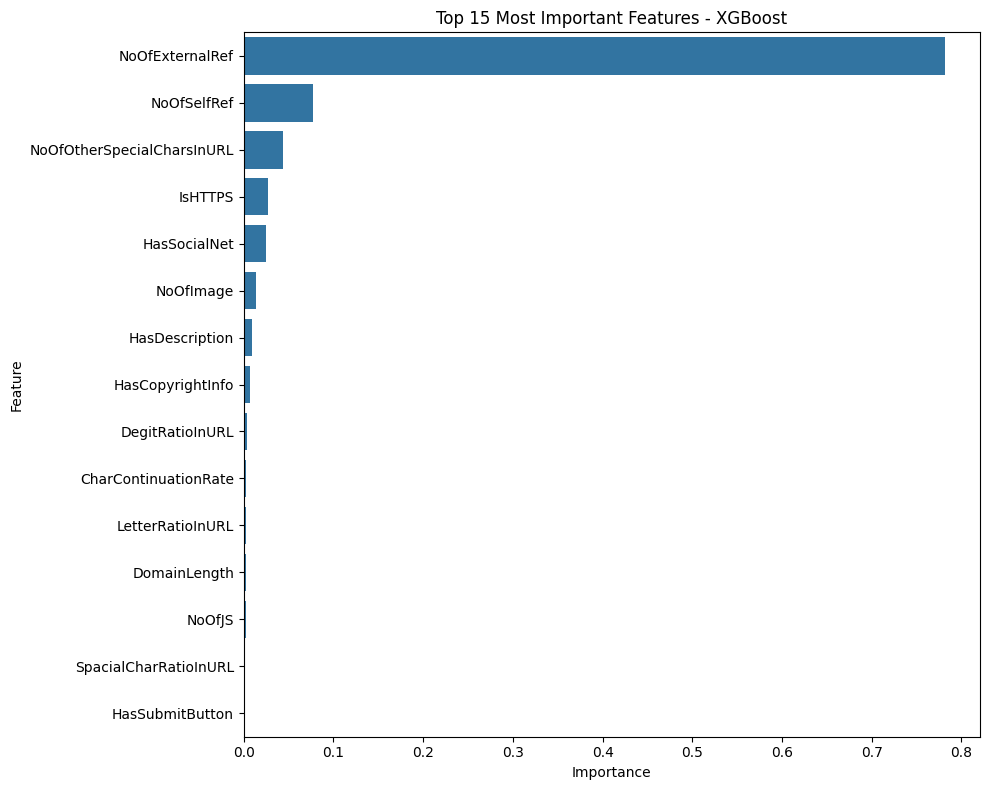

In [56]:
best_model_name = results_df.index[0]
best_model = models[best_model_name]
print(f"Best Model: {best_model_name}")

importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance":best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

top_features = importance_df.head(15)
plt.figure(figsize=(10,8))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features - XGBoost")
plt.tight_layout()
plt.show()